<a href="https://colab.research.google.com/github/xwx-codingweb/XIA_DSPN_S26/blob/master/ExerciseSubmissions/17_regularized-regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 17: Regularized regression

This homework assignment is designed to give you an intuition as an interesting property of regularization in the context of ultra-high dimensional statistical problems.

You won't need to load in any data for this homework.

---
## 1. Simulating & visualizing data (2 points)

We are going to be looking at what happens in the context where $p>n$. In order to have total control over our data, we will use simulations for this homework. First, we will need to load the `glmnet`, `tidyverse`, and `ggplot2` libraries for this assignment.


In [6]:
# WRITE YOUR CODE HERE
install.packages("glmnet")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’




In [7]:
library(glmnet)
library(tidyverse)
library(ggplot2)

Loading required package: Matrix

Loaded glmnet 4.1-10

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


We are going to generate a data set with complex structure and try to recover it using polynomial models. For simplicity sake, use the following code to produce a response variable, $y$ that has complex structure.

*Hint: Look up what a cosine function looks like if you need a reminder.*

In [16]:
# Generate data
set.seed(121)
sigma_noise = .5
x=seq(-9,9,by=.18)
n=length(x)
y = 0.1*x + cos(x) + cos(x/20)+rnorm(n,sd=sigma_noise)

[1] 101


(a) Break the data into a training set (n=50) and test set (n=51) using the `sample` function to randomly select subsets of x and y.  Make a separate data frame for the training and test data.

(**Note**: *Do not* just take the first 50 observations to be the training set and last 51 observations to be the test set.)

In [35]:
# WRITE YOUR CODE HERE
set.seed(13)

train_idx <- sample(1:n, 50)

train <- data.frame(x = x[train_idx], y = y[train_idx])
test  <- data.frame(x = x[-train_idx], y = y[-train_idx])


(b) Plot the training data ($x$ \& $y$). Describe the relationship that you see in the training data.

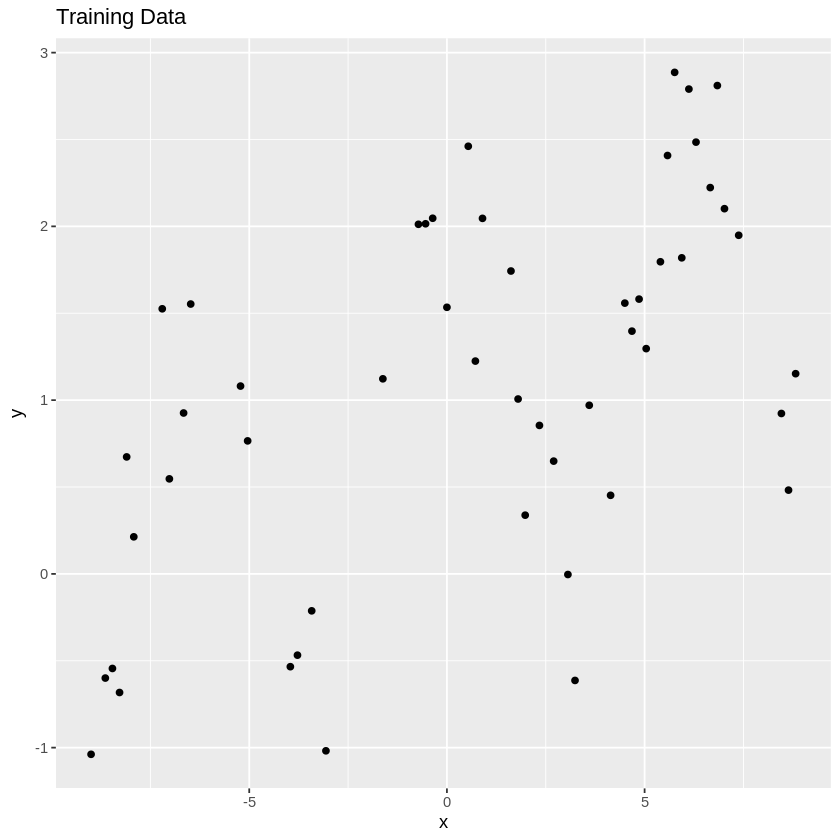

In [10]:
# WRITE YOUR CODE HERE
ggplot(train, aes(x = x, y = y)) +
  geom_point() +
  labs(title = "Training Data")

How would you describe the relationship between $x$ and $y$ based on this plot?

> The relationship is nonlinear and oscillatory, with a smooth wave-like pattern due to cosine components.

---
## 2. Bias-variance tradeoff: polynomial regression (4 points)

Recall that in polynomial regression we increase model complexity by expanding $x$ out to the power $k$ (which we call degree).

$$
Y = \hat{\beta}_0 + \sum_{j=1}^K \hat{\beta}_j X^j
\;=\; \operatorname{poly}(X, K)
$$

(a) Fit a 2nd degree polynomial regression model to the training data. Plot the results.


*Hint: Use the* `help` *function to see how to use the* `stat_smooth()` *and* `poly()` *functions.*

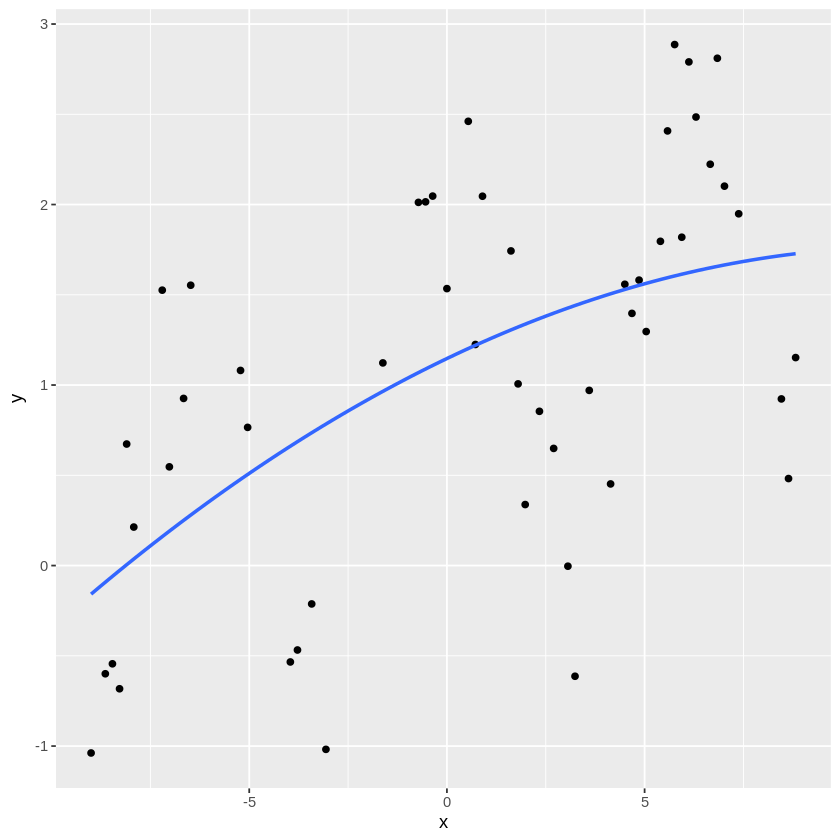

In [11]:
# WRITE YOUR CODE HERE
ggplot(train, aes(x=x, y=y)) +
  geom_point() +
  stat_smooth(method="lm", formula = y ~ poly(x,2), se=FALSE)

How well does this 2nd degree polynomial model qualitatively fit the data? Could it do better?

> The 2nd-degree model underfits and fails to capture the oscillatory structure.

(b) Fit a 12th degree polynomial to the data. Does this do qualitatively better or worse than the 2nd degree model?

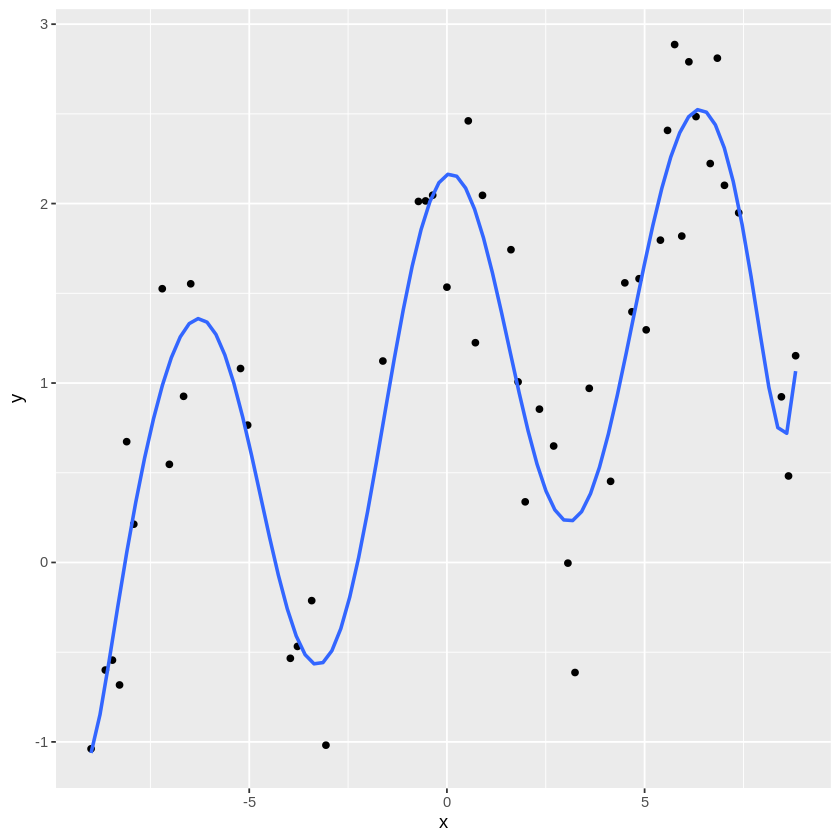

In [12]:
# WRITE YOUR CODE HERE
ggplot(train, aes(x=x, y=y)) +
  geom_point() +
  stat_smooth(method="lm", formula = y ~ poly(x,12), se=FALSE)

> The 12th-degree model fits better but may begin to overfit noise.
>

(c) Modify the loop below to estimate the bias-variance tradeoff as model complexity (i.e., degree of the polynomial model, $k$) increases from 2 to 50. Use the training data to fit the model and test data to evaluate its predictive accuracy.

Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.


(**Note**: We are using median accuracies here because there are often 1 or 2 outlier values in the higher degree polynomial models that can throw off the accuracy estimates).

Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in p

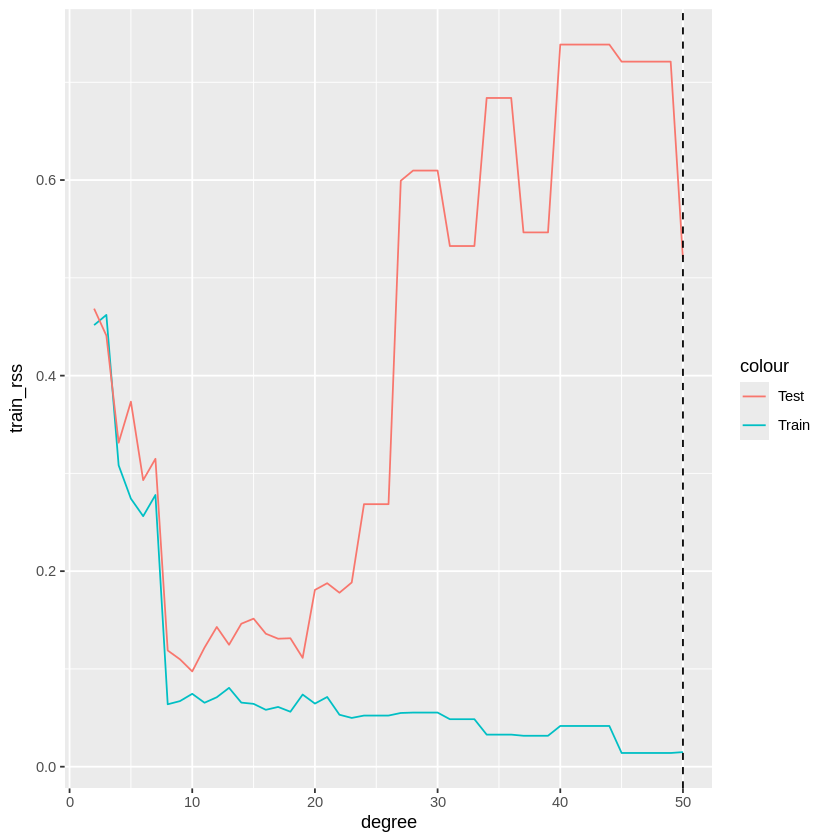

In [81]:
degree = seq(2,50)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {


  model <- lm(y ~ poly(x, k, raw=TRUE), data = train)

  train_pred <- predict(model, train)
  test_pred  <- predict(model, test)

  train_rss[k-1] <- median((train$y - train_pred)^2)
  test_rss[k-1]  <- median((test$y - test_pred)^2)
}

df <- data.frame(degree, train_rss, test_rss)


ggplot(df, aes(x=degree)) +
  geom_line(aes(y=train_rss, color="Train")) +
  geom_line(aes(y=test_rss, color="Test")) +
  geom_vline(xintercept=50, linetype="dashed")

What do you see as $k$ increase?

> Training error decreases as model complexity increases, while test error decreases initially and then increases, showing overfitting.
>

(d) Now copy the code above and let's see what happens when we go beyond $p=n$ (remember, in this case $k=p$). Test polynomial models up to $k=150$. Visualize your results by plotting the *median* squared error for the training data and test data as a function of polynomial degree.

Use the `geom_vline()` function in `ggplot` to draw a vertical line where $k=n$ (here $n$ is the number of observations in the training set). This will make it clear where we cross the threshold for finding *unique* solutions in our data.



Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, train):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in predict.lm(model, test):
“prediction from rank-deficient fit; attr(*, "non-estim") has doubtful cases”
Warning message in p

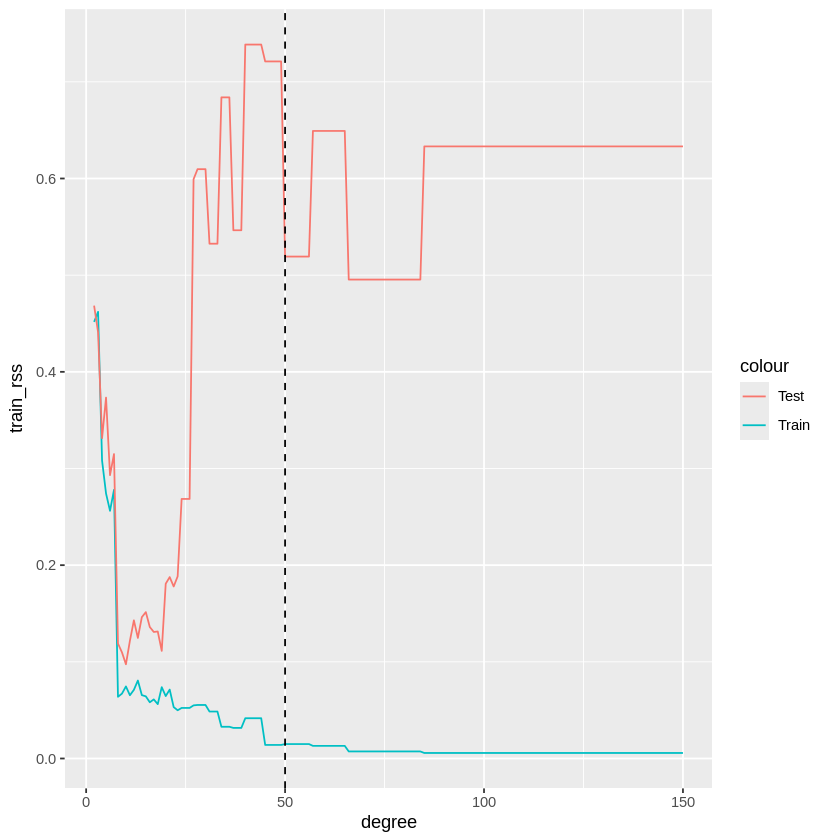

In [79]:
# Now do the variance-bias trade off analysis using regular regression
degree = seq(2,150)

# Need to setup your output vectors
train_rss = matrix(data=NA,nrow=length(degree),ncol=1)
test_rss = matrix(data=NA,nrow=length(degree),ncol=1)

for (k in degree) {

  model <- lm(y ~ poly(x, k, raw=TRUE), data = train)

  train_pred <- predict(model, train)
  test_pred  <- predict(model, test)

  train_rss[k-1] <- median((train$y - train_pred)^2)
  test_rss[k-1]  <- median((test$y - test_pred)^2)
}

df <- data.frame(degree, train_rss, test_rss)

ggplot(df, aes(x=degree)) +
  geom_line(aes(y=train_rss, color="Train")) +
  geom_line(aes(y=test_rss, color="Test")) +
  geom_vline(xintercept=50, linetype="dashed")

What do you see as $k$ gets larger than $n$?

> When k exceeds n, training error becomes extremely low, but test error increases sharply due to severe overfitting and instability.

---
## 3. Applying regularization to the model fits (2 points)

Repeat the previous bias-variance tradeoff test, going up to $k=150$, but now use ridge regression with a sparsity parameter of $\lambda=0.00005$. Plot your results the same way as last time.

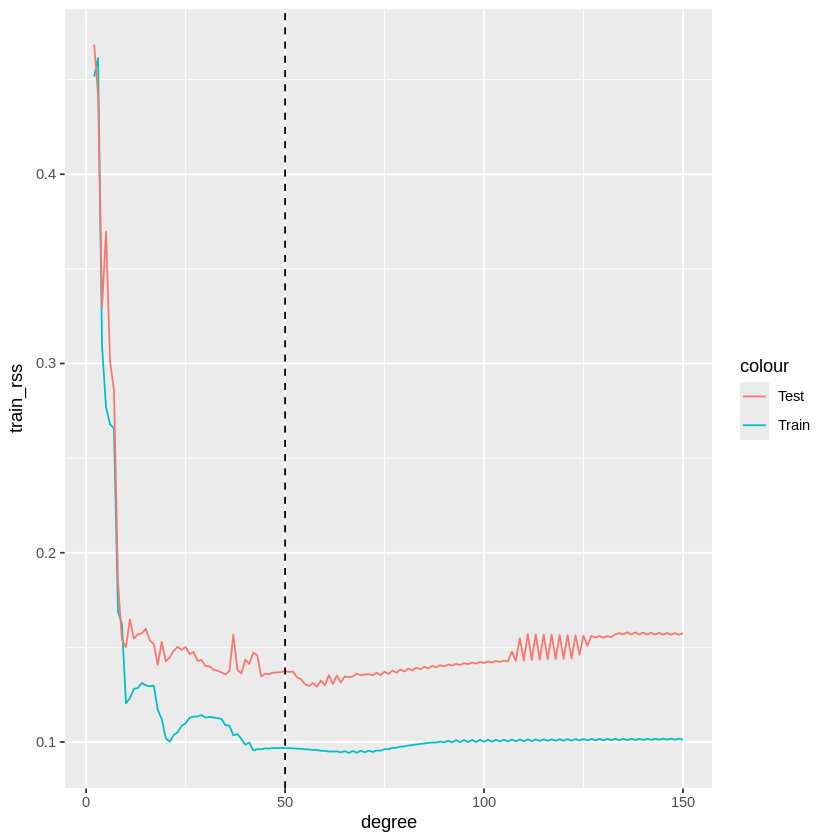

In [80]:
lambda = 0.00005
degree = seq(2,150)

train_rss = rep(NA, length(degree))
test_rss  = rep(NA, length(degree))

for (k in degree) {

  X_train <- model.matrix(y ~ poly(x,k, raw=TRUE), data=train)[,-1]
  X_test  <- model.matrix(y ~ poly(x,k, raw=TRUE), data=test)[,-1]

  ridge_model <- glmnet(X_train, train$y, alpha=0, lambda=lambda)

  train_pred <- predict(ridge_model, s=lambda, newx=X_train)
  test_pred  <- predict(ridge_model, s=lambda, newx=X_test)

  train_rss[k-1] <- median((train$y - train_pred)^2)
  test_rss[k-1]  <- median((test$y - test_pred)^2)
}

df <- data.frame(degree, train_rss, test_rss)

ggplot(df, aes(x=degree)) +
  geom_line(aes(y=train_rss, color="Train")) +
  geom_line(aes(y=test_rss, color="Test")) +
  geom_vline(xintercept=50, linetype="dashed")


What happens now when $k$ gets larger than $n$?

> With ridge regression, test error remains stable even when k > n, showing reduced overfitting due to coefficient shrinkage.

---
## 4. Reflection (2 points)

The simulations above should have shown that, when applying a regularization (i.e., a sparsity constraint), the behavior of the bias-variance tradeoff changes. Explain why this happens.

> Regularization reduces model variance by shrinking coefficients, preventing extreme values in high-dimensional settings. This stabilizes the model and improves generalization, even when the number of predictors exceeds the number of observations.

---
## Bonus (1 extra credit point)
Recall that the $p=n$ threshold defines the limit for finding a *unique* solution to $Y=F(X)$ (i.e., there is only one combination of regression coefficients that is *best* at explaining variance in $Y$). With this in mind, what is regularization doing that works around this upper limit?

> When p ≥ n, there are infinitely many solutions that fit the data perfectly. Regularization imposes a penalty on coefficient size, selecting the solution with the smallest norm, which ensures a unique and stable solution.

**DUE:** 5pm EST, April 7, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*